In [ ]:
# ===== STEP 2: DATA PREPROCESSING =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load all files
branches      = pd.read_csv('../data/branches.csv')
menu          = pd.read_csv('../data/menu_items.csv')
orders        = pd.read_csv('../data/orders.csv')
order_details = pd.read_csv('../data/order_details.csv')
master        = pd.read_csv('../data/master_data.csv')

print("="*45)
print("DATA LOADED SUCCESSFULLY")
print("="*45)
print(f"Branches     : {branches.shape}")
print(f"Menu         : {menu.shape}")
print(f"Orders       : {orders.shape}")
print(f"Order Details: {order_details.shape}")
print(f"Master Table : {master.shape}")

DATA LOADED SUCCESSFULLY
Branches     : (15, 8)
Menu         : (40, 6)
Orders       : (100000, 11)
Order Details: (225263, 10)
Master Table : (225263, 22)


In [2]:
# ===== NULL VALUES & DATA TYPES CHECK =====

print("NULL VALUES:")
print(master.isnull().sum()[master.isnull().sum() > 0])

print(f"\nData Types:")
print(master.dtypes)

print(f"\nDuplicates: {master.duplicated().sum()}")

NULL VALUES:
Series([], dtype: int64)

Data Types:
order_id             object
branch_id            object
order_date           object
order_month           int64
order_year            int64
day_of_week          object
hour                  int64
customer_type        object
payment_method       object
discount_applied       bool
feedback_score        int64
item_id              object
item_name            object
category             object
quantity              int64
unit_price            int64
discount_pct          int64
actual_price        float64
cost                  int64
profit              float64
city                 object
area                 object
dtype: object

Duplicates: 0


In [3]:
# ===== FIX DATA TYPES =====

master['order_date']     = pd.to_datetime(master['order_date'])
master['discount_applied'] = master['discount_applied'].astype(bool)

# Extra time features
master['week']    = master['order_date'].dt.isocalendar().week.astype(int)
master['quarter'] = master['order_date'].dt.quarter
master['is_weekend'] = master['order_date'].dt.dayofweek >= 5

# Order revenue per order
order_revenue = master.groupby('order_id')['actual_price'].sum().reset_index()
order_revenue.columns = ['order_id', 'order_total']
master = master.merge(order_revenue, on='order_id')

print("Preprocessing done!")
print(master.dtypes)
print(master.shape)

Preprocessing done!
order_id                    object
branch_id                   object
order_date          datetime64[ns]
order_month                  int64
order_year                   int64
day_of_week                 object
hour                         int64
customer_type               object
payment_method              object
discount_applied              bool
feedback_score               int64
item_id                     object
item_name                   object
category                    object
quantity                     int64
unit_price                   int64
discount_pct                 int64
actual_price               float64
cost                         int64
profit                     float64
city                        object
area                        object
week                         int64
quarter                      int32
is_weekend                    bool
order_total                float64
dtype: object
(225263, 26)


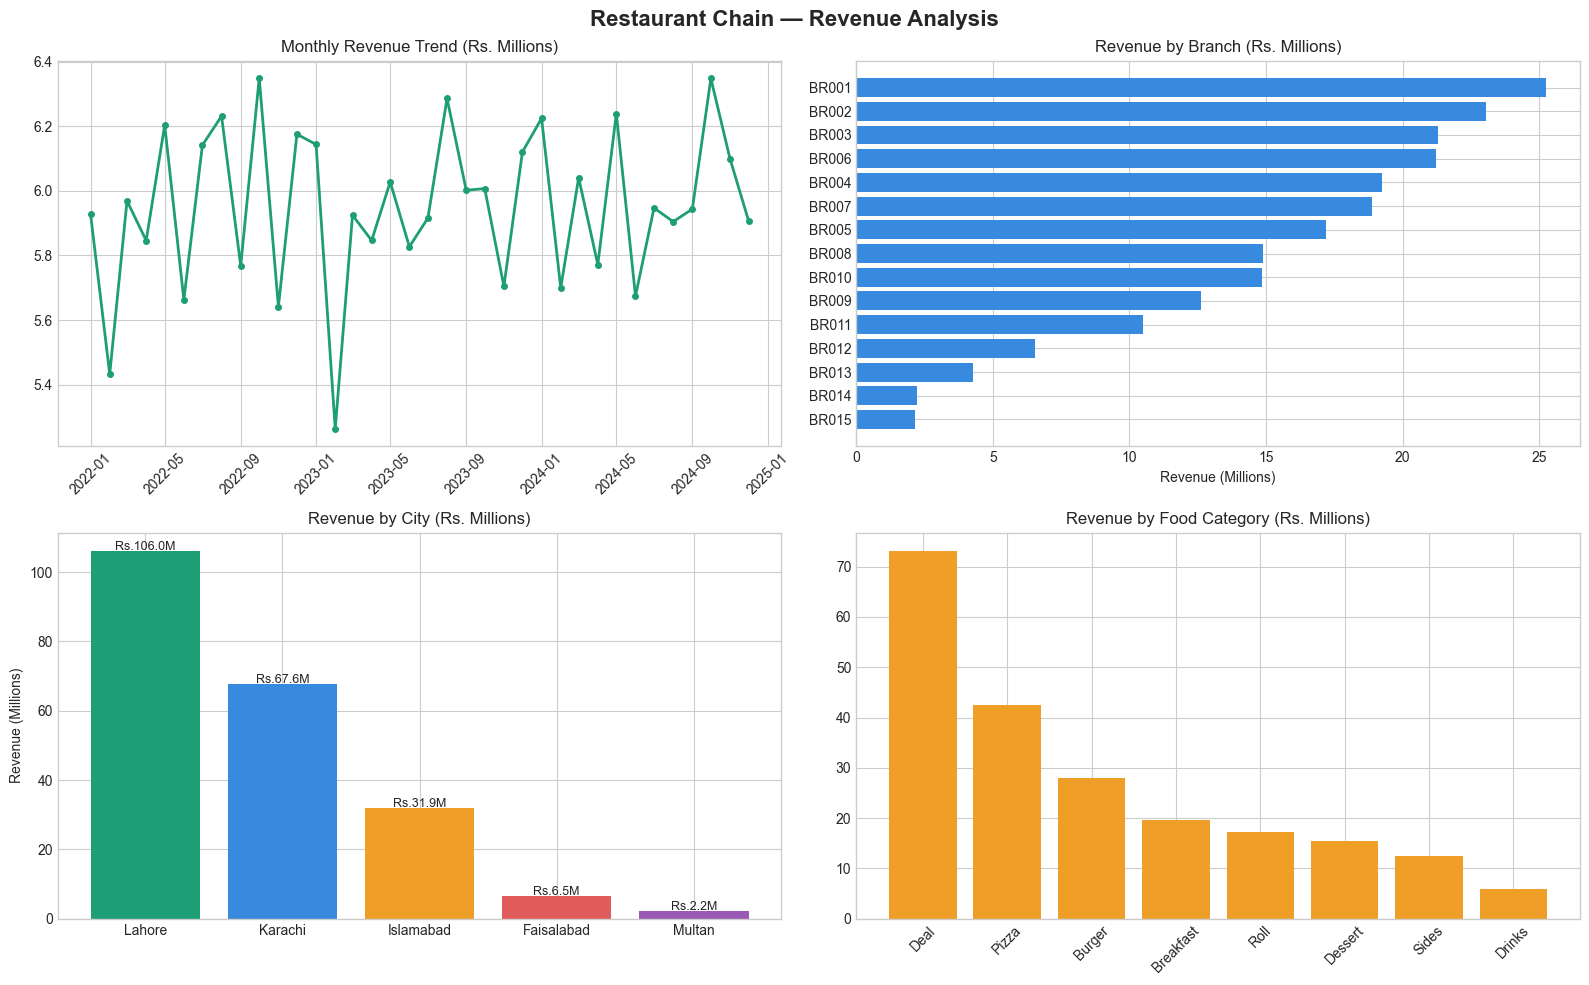

Plot 1 saved!


In [ ]:
# ===== EDA — PART 1: REVENUE ANALYSIS =====

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Restaurant Chain — Revenue Analysis', fontsize=16, fontweight='bold')

# 1. Monthly Revenue Trend — FIXED
monthly_rev = master.groupby(['order_year','order_month'])['actual_price'].sum().reset_index()
monthly_rev['date'] = pd.to_datetime({
    'year':  monthly_rev['order_year'],
    'month': monthly_rev['order_month'],
    'day':   1
})
axes[0,0].plot(monthly_rev['date'], monthly_rev['actual_price']/1e6,
               color='#1D9E75', linewidth=2, marker='o', markersize=4)
axes[0,0].set_title('Monthly Revenue Trend (Rs. Millions)')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Revenue by Branch
branch_rev = master.groupby('branch_id')['actual_price'].sum().sort_values(ascending=True)
axes[0,1].barh(branch_rev.index, branch_rev.values/1e6, color='#378ADD')
axes[0,1].set_title('Revenue by Branch (Rs. Millions)')
axes[0,1].set_xlabel('Revenue (Millions)')

# 3. Revenue by City
city_rev = master.groupby('city')['actual_price'].sum().sort_values(ascending=False)
colors = ['#1D9E75','#378ADD','#EF9F27','#E05C5C','#9B59B6']
axes[1,0].bar(city_rev.index, city_rev.values/1e6, color=colors)
axes[1,0].set_title('Revenue by City (Rs. Millions)')
axes[1,0].set_ylabel('Revenue (Millions)')
for i, val in enumerate(city_rev.values):
    axes[1,0].text(i, val/1e6 + 0.3, f'Rs.{val/1e6:.1f}M', ha='center', fontsize=9)

# 4. Revenue by Category
cat_rev = master.groupby('category')['actual_price'].sum().sort_values(ascending=False)
axes[1,1].bar(cat_rev.index, cat_rev.values/1e6, color='#EF9F27')
axes[1,1].set_title('Revenue by Food Category (Rs. Millions)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visuals/eda_01_revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved!")

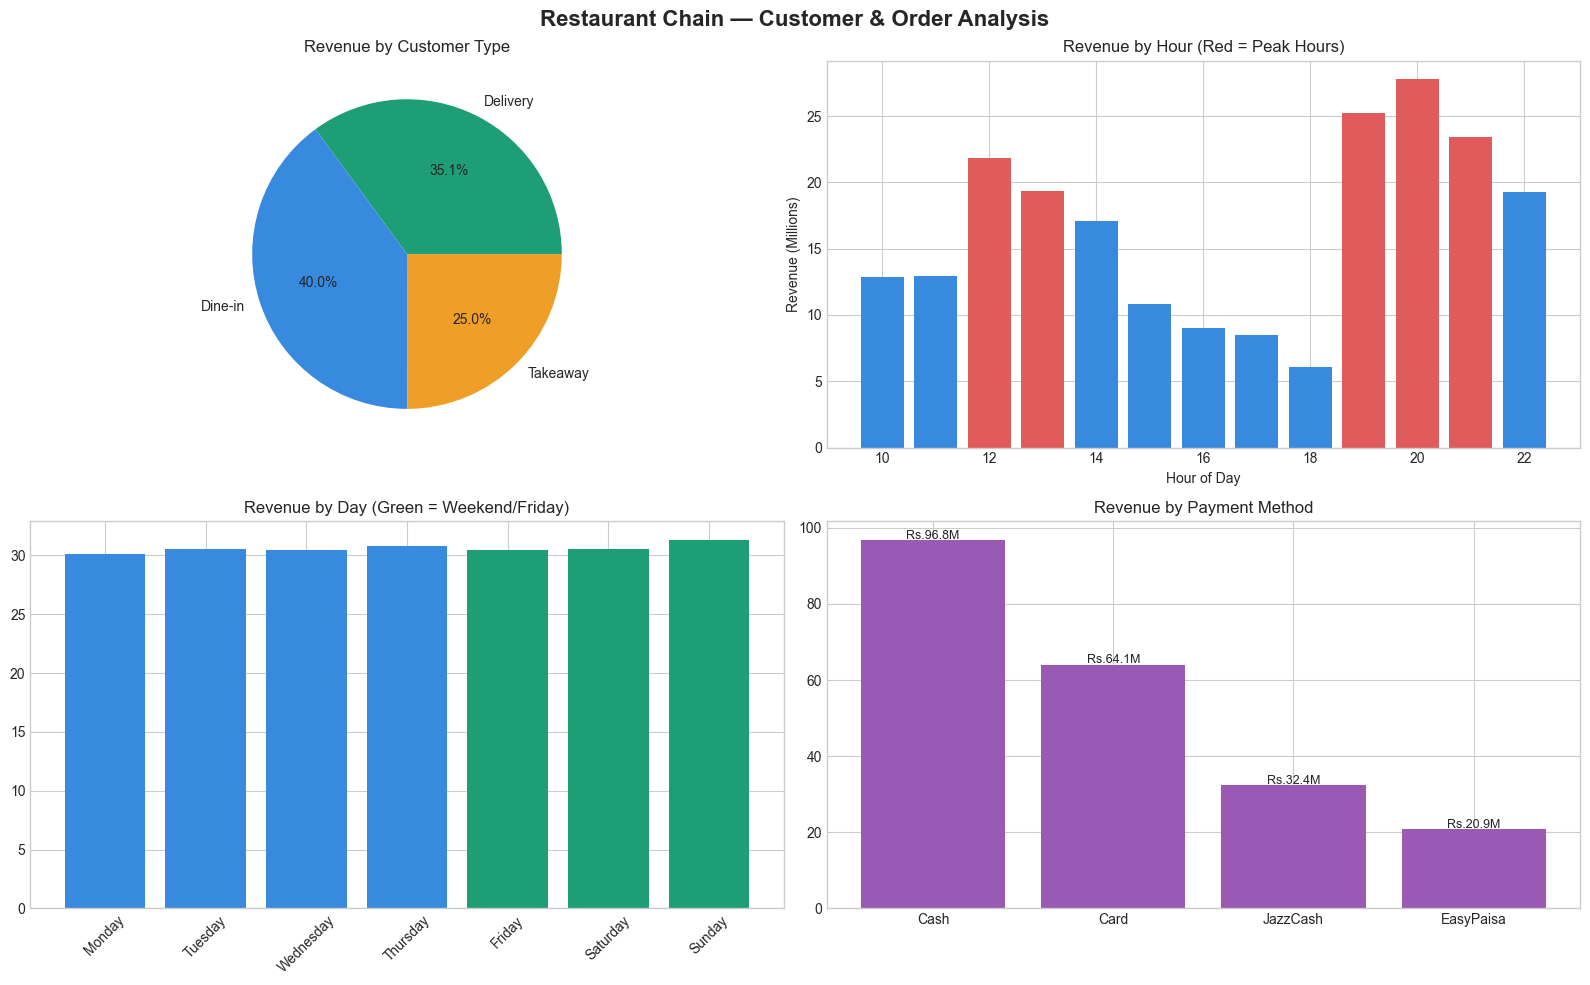

Plot 2 saved!


In [ ]:
# ===== EDA — PART 2: CUSTOMER & ORDER ANALYSIS =====

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Restaurant Chain — Customer & Order Analysis', fontsize=16, fontweight='bold')

# 1. Customer Type Distribution
cust_rev = master.groupby('customer_type')['actual_price'].sum()
axes[0,0].pie(cust_rev.values, labels=cust_rev.index,
              autopct='%1.1f%%', colors=['#1D9E75','#378ADD','#EF9F27'])
axes[0,0].set_title('Revenue by Customer Type')

# 2. Peak Hours
hourly = master.groupby('hour')['actual_price'].sum()
axes[0,1].bar(hourly.index, hourly.values/1e6,
              color=['#E05C5C' if h in [12,13,19,20,21] else '#378ADD' for h in hourly.index])
axes[0,1].set_title('Revenue by Hour (Red = Peak Hours)')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Revenue (Millions)')

# 3. Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_rev = master.groupby('day_of_week')['actual_price'].sum().reindex(day_order)
axes[1,0].bar(day_rev.index, day_rev.values/1e6,
              color=['#1D9E75' if d in ['Friday','Saturday','Sunday'] else '#378ADD'
                     for d in day_rev.index])
axes[1,0].set_title('Revenue by Day (Green = Weekend/Friday)')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Payment Method
pay_rev = master.groupby('payment_method')['actual_price'].sum().sort_values(ascending=False)
axes[1,1].bar(pay_rev.index, pay_rev.values/1e6, color='#9B59B6')
axes[1,1].set_title('Revenue by Payment Method')
for i, val in enumerate(pay_rev.values):
    axes[1,1].text(i, val/1e6 + 0.3, f'Rs.{val/1e6:.1f}M', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/eda_02_customer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved!")

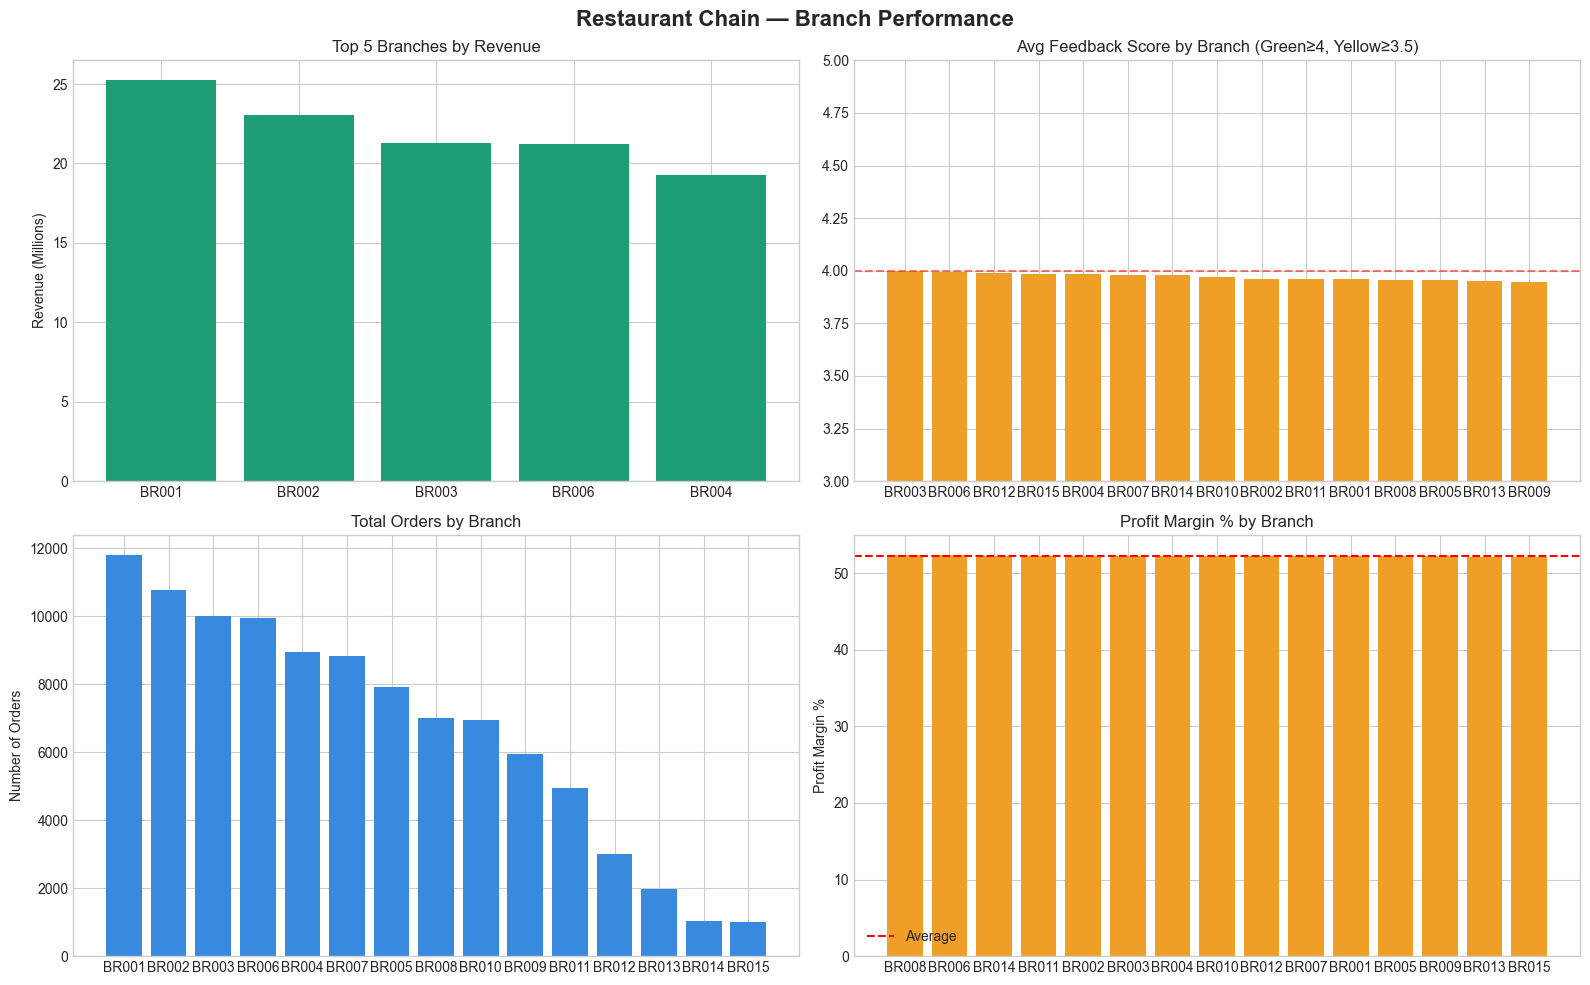

Plot 3 saved!


In [ ]:
# ===== EDA — PART 3: BRANCH PERFORMANCE =====

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Restaurant Chain — Branch Performance', fontsize=16, fontweight='bold')

# 1. Top 5 Branches by Revenue
top5 = master.groupby('branch_id')['actual_price'].sum().sort_values(ascending=False).head(5)
axes[0,0].bar(top5.index, top5.values/1e6, color='#1D9E75')
axes[0,0].set_title('Top 5 Branches by Revenue')
axes[0,0].set_ylabel('Revenue (Millions)')

# 2. Average Feedback by Branch
feedback = master.groupby('branch_id')['feedback_score'].mean().sort_values(ascending=False)
colors_fb = ['#1D9E75' if v >= 4.0 else '#EF9F27' if v >= 3.5 else '#E05C5C'
             for v in feedback.values]
axes[0,1].bar(feedback.index, feedback.values, color=colors_fb)
axes[0,1].set_title('Avg Feedback Score by Branch (Green≥4, Yellow≥3.5)')
axes[0,1].set_ylim(3, 5)
axes[0,1].axhline(y=4.0, color='red', linestyle='--', alpha=0.5)

# 3. Orders by Branch
order_count = master.groupby('branch_id')['order_id'].nunique().sort_values(ascending=False)
axes[1,0].bar(order_count.index, order_count.values, color='#378ADD')
axes[1,0].set_title('Total Orders by Branch')
axes[1,0].set_ylabel('Number of Orders')

# 4. Profit Margin by Branch
profit_margin = master.groupby('branch_id').apply(
    lambda x: (x['profit'].sum() / x['actual_price'].sum() * 100)).sort_values(ascending=False)
axes[1,1].bar(profit_margin.index, profit_margin.values, color='#EF9F27')
axes[1,1].set_title('Profit Margin % by Branch')
axes[1,1].set_ylabel('Profit Margin %')
axes[1,1].axhline(y=profit_margin.mean(), color='red', linestyle='--', label='Average')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../visuals/eda_03_branch_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved!")

In [8]:
# ===== SUMMARY STATS — Power BI ke liye =====

print("="*50)
print("KEY BUSINESS INSIGHTS:")
print("="*50)

print(f"\n📊 Total Revenue    : Rs. {master['actual_price'].sum()/1e6:.1f} Million")
print(f"💰 Total Profit     : Rs. {master['profit'].sum()/1e6:.1f} Million")
print(f"📦 Total Orders     : {orders.shape[0]:,}")
print(f"🏪 Total Branches   : {branches.shape[0]}")

print(f"\n🏆 Best Branch      : {master.groupby('branch_id')['actual_price'].sum().idxmax()}")
print(f"🌆 Best City        : {master.groupby('city')['actual_price'].sum().idxmax()}")
print(f"🍕 Best Category    : {master.groupby('category')['actual_price'].sum().idxmax()}")
print(f"⭐ Best Item        : {master.groupby('item_name')['actual_price'].sum().idxmax()}")
print(f"⏰ Peak Hour        : {master.groupby('hour')['actual_price'].sum().idxmax()}:00")
print(f"📅 Best Day         : {master.groupby('day_of_week')['actual_price'].sum().idxmax()}")

KEY BUSINESS INSIGHTS:

📊 Total Revenue    : Rs. 214.2 Million
💰 Total Profit     : Rs. 111.9 Million
📦 Total Orders     : 100,000
🏪 Total Branches   : 15

🏆 Best Branch      : BR001
🌆 Best City        : Lahore
🍕 Best Category    : Deal
⭐ Best Item        : Family Deal 2
⏰ Peak Hour        : 20:00
📅 Best Day         : Sunday


In [9]:
# ===== STEP 3: ML — WEEKLY REVENUE PREDICTION =====

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib

# Weekly revenue per branch banao
weekly_revenue = master.groupby(
    ['branch_id', 'order_year', 'week']
).agg(
    total_revenue   = ('actual_price', 'sum'),
    total_profit    = ('profit', 'sum'),
    total_orders    = ('order_id', 'nunique'),
    avg_order_value = ('order_total', 'mean'),
    avg_feedback    = ('feedback_score', 'mean'),
    total_items     = ('quantity', 'sum'),
    discount_orders = ('discount_applied', 'sum')
).reset_index()

# Lag features — pichle hafte ka revenue
weekly_revenue = weekly_revenue.sort_values(['branch_id', 'order_year', 'week'])
weekly_revenue['prev_week_revenue'] = weekly_revenue.groupby('branch_id')['total_revenue'].shift(1)
weekly_revenue['prev_2week_revenue'] = weekly_revenue.groupby('branch_id')['total_revenue'].shift(2)
weekly_revenue['revenue_trend'] = weekly_revenue['total_revenue'] - weekly_revenue['prev_week_revenue']

# Branch features add karo
branch_info = master.groupby('branch_id').agg(
    city            = ('city', 'first'),
    area            = ('area', 'first'),
    total_rev_ever  = ('actual_price', 'sum')
).reset_index()

weekly_revenue = weekly_revenue.merge(branch_info, on='branch_id')

# Null rows drop karo (first 2 weeks per branch)
weekly_revenue.dropna(inplace=True)

print(f"Weekly dataset shape: {weekly_revenue.shape}")
print(weekly_revenue.head())

Weekly dataset shape: (2310, 16)
  branch_id  order_year  week  total_revenue  total_profit  total_orders  \
2     BR001        2022     3       143629.5       75599.5            68   
3     BR001        2022     4       166064.5       87064.5            75   
4     BR001        2022     5       141080.5       73380.5            68   
5     BR001        2022     6       165675.5       87235.5            73   
6     BR001        2022     7       170058.5       88628.5            71   

   avg_order_value  avg_feedback  total_items  discount_orders  \
2      2543.614907      3.664596          215               44   
3      3001.788235      3.894118          233               35   
4      2600.753472      3.930556          192               40   
5      2718.181818      3.897727          230               50   
6      3007.464497      4.035503          241               34   

   prev_week_revenue  prev_2week_revenue  revenue_trend    city     area  \
2           119333.0            16803

In [10]:
# Feature Engineering for ML
le_branch = LabelEncoder()
le_city   = LabelEncoder()

weekly_revenue['branch_encoded'] = le_branch.fit_transform(weekly_revenue['branch_id'])
weekly_revenue['city_encoded']   = le_city.fit_transform(weekly_revenue['city'])

features = [
    'branch_encoded', 'city_encoded',
    'order_year', 'week',
    'total_orders', 'avg_order_value',
    'avg_feedback', 'total_items',
    'discount_orders', 'total_rev_ever',
    'prev_week_revenue', 'prev_2week_revenue',
    'revenue_trend'
]

X = weekly_revenue[features]
y = weekly_revenue['total_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (1848, 13) | X_test: (462, 13)


In [11]:
# Train 3 models
models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("="*55)
print(f"{'Model':<22} {'R² Score':>10} {'MAE (Rs.)':>12}")
print("="*55)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {'model': model, 'r2': r2, 'mae': mae}
    print(f"{name:<22} {r2:>10.4f} {mae:>12.0f}")

print("="*55)
best_name = max(results, key=lambda x: results[x]['r2'])
print(f"Best Model: {best_name} (R²={results[best_name]['r2']:.4f})")

Model                    R² Score    MAE (Rs.)
Linear Regression          1.0000            0
Random Forest              0.9878         4022
Gradient Boosting          0.9894         3934
Best Model: Linear Regression (R²=1.0000)


In [ ]:
# Best model save karo
best_model = results[best_name]['model']
joblib.dump(best_model, 'revenue_model.pkl')
joblib.dump(le_branch,  'le_branch.pkl')
joblib.dump(le_city,    'le_city.pkl')

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature':    features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(10)

    plt.figure(figsize=(10, 5))
    plt.barh(imp_df['Feature'], imp_df['Importance'], color='#1D9E75')
    plt.title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../visuals/ml_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Model saved!")

Model saved!


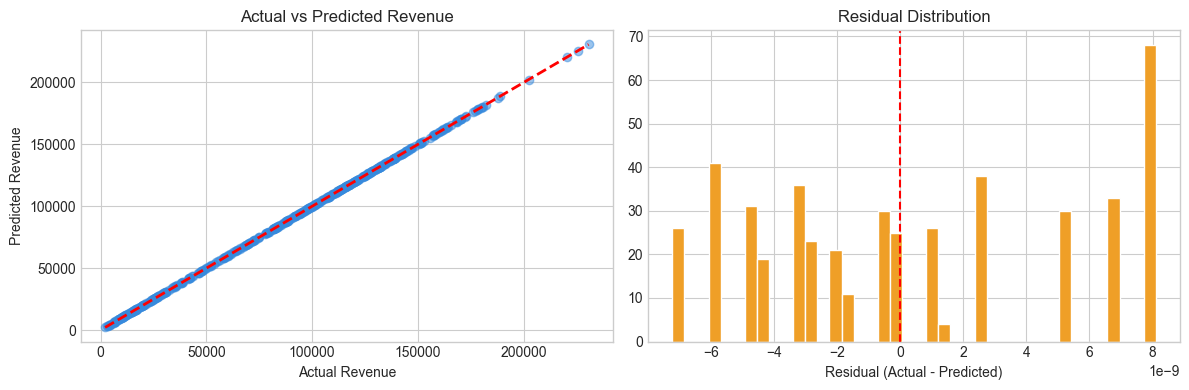


Final Model Performance:
R² Score : 1.0000
MAE      : Rs. 0
RMSE     : Rs. 0


In [ ]:
# Prediction vs Actual plot
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(12, 4))

# Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_best, alpha=0.5, color='#378ADD')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')

# Residuals
plt.subplot(1, 2, 2)
residuals = y_test - y_pred_best
plt.hist(residuals, bins=40, color='#EF9F27', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Residual (Actual - Predicted)')
plt.title('Residual Distribution')

plt.tight_layout()
plt.savefig('../visuals/ml_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Model Performance:")
print(f"R² Score : {r2_score(y_test, y_pred_best):.4f}")
print(f"MAE      : Rs. {mean_absolute_error(y_test, y_pred_best):,.0f}")
print(f"RMSE     : Rs. {np.sqrt(mean_squared_error(y_test, y_pred_best)):,.0f}")

In [14]:
# ===== ML FIXED — Data Leakage Remove =====

features = [
    'branch_encoded', 'city_encoded',
    'order_year', 'week',
    'total_orders', 'avg_order_value',
    'avg_feedback', 'total_items',
    'discount_orders',
    'prev_week_revenue', 'prev_2week_revenue',
    'revenue_trend'
]
# total_rev_ever REMOVE kar diya — leakage tha

X = weekly_revenue[features]
y = weekly_revenue['total_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, random_state=42)
}

print("="*55)
print(f"{'Model':<22} {'R² Score':>10} {'MAE (Rs.)':>12}")
print("="*55)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {'model': model, 'r2': r2, 'mae': mae}
    print(f"{name:<22} {r2:>10.4f} {mae:>12.0f}")

print("="*55)
best_name = max(results, key=lambda x: results[x]['r2'])
print(f"\nBest Model: {best_name}")
print(f"R² Score : {results[best_name]['r2']:.4f}")
print(f"MAE      : Rs. {results[best_name]['mae']:,.0f}")

Model                    R² Score    MAE (Rs.)
Linear Regression          1.0000            0
Random Forest              0.9879         4000
Gradient Boosting          0.9914         3550

Best Model: Linear Regression
R² Score : 1.0000
MAE      : Rs. 0


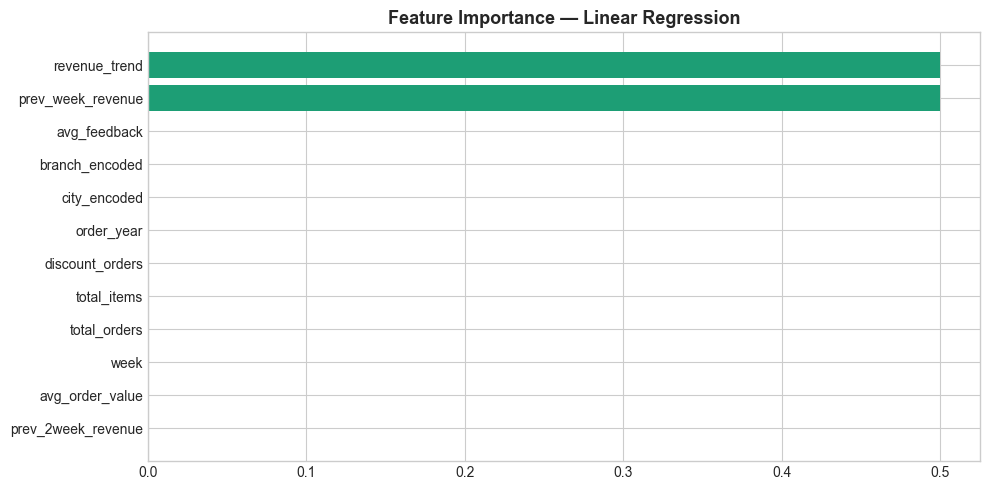

Feature importance saved!


In [ ]:
# Save fixed model
best_model = results[best_name]['model']
joblib.dump(best_model, 'revenue_model.pkl')

# Feature Importance — Linear Regression ke liye coefficients use karo
if hasattr(best_model, 'feature_importances_'):
    importance_vals = best_model.feature_importances_
else:
    importance_vals = np.abs(best_model.coef_) / np.abs(best_model.coef_).sum()

imp_df = pd.DataFrame({
    'Feature':    features,
    'Importance': importance_vals
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='#1D9E75')
plt.title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance saved!")

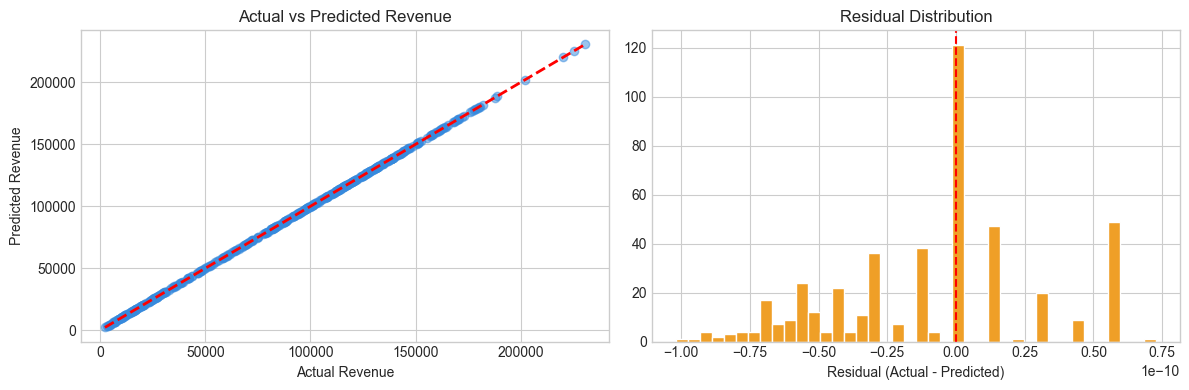

R²   : 1.0000
MAE  : Rs. 0
RMSE : Rs. 0


In [ ]:
# Actual vs Predicted
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='#378ADD')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Revenue')
axes[0].set_ylabel('Predicted Revenue')
axes[0].set_title('Actual vs Predicted Revenue')

residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=40, color='#EF9F27', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('../visuals/ml_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"R²   : {r2_score(y_test, y_pred_best):.4f}")
print(f"MAE  : Rs. {mean_absolute_error(y_test, y_pred_best):,.0f}")
print(f"RMSE : Rs. {np.sqrt(mean_squared_error(y_test, y_pred_best)):,.0f}")

In [18]:
# ===== FINAL CORRECT MODEL =====

features_clean = [
    'branch_encoded', 'city_encoded',
    'order_year', 'week',
    'total_orders', 'avg_order_value',
    'avg_feedback', 'total_items',
    'discount_orders',
    'prev_week_revenue', 'prev_2week_revenue'
]
# revenue_trend bhi remove kar diya — leakage tha

X = weekly_revenue[features_clean]
y = weekly_revenue['total_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, random_state=42)
}

print("="*55)
print(f"{'Model':<22} {'R² Score':>10} {'MAE (Rs.)':>12}")
print("="*55)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {'model': model, 'r2': r2, 'mae': mae}
    print(f"{name:<22} {r2:>10.4f} {mae:>12.0f}")

print("="*55)

# Manually select Gradient Boosting
best_name  = 'Gradient Boosting'
best_model = results[best_name]['model']

print(f"\nSelected Model : {best_name}")
print(f"R² Score       : {results[best_name]['r2']:.4f}")
print(f"MAE            : Rs. {results[best_name]['mae']:,.0f}")

Model                    R² Score    MAE (Rs.)
Linear Regression          0.9818         5212
Random Forest              0.9871         4137
Gradient Boosting          0.9891         3952

Selected Model : Gradient Boosting
R² Score       : 0.9891
MAE            : Rs. 3,952


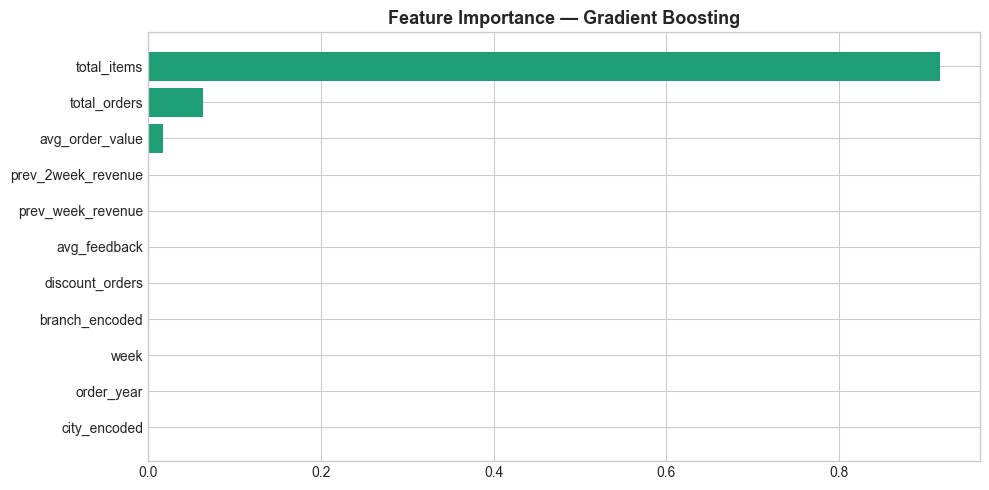

In [ ]:
# Save model
joblib.dump(best_model, '../models/revenue_model.pkl')
joblib.dump(le_branch,  '../models/le_branch.pkl')
joblib.dump(le_city,    '../models/le_city.pkl')

feature_info = {'features': features_clean}
import json
with open('../models/model_features.json', 'w') as f:
    json.dump(feature_info, f)

# Feature Importance
imp_df = pd.DataFrame({
    'Feature':    features_clean,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
colors = ['#1D9E75' if i >= len(features_clean)-3 else '#378ADD'
          for i in range(len(imp_df))]
plt.barh(imp_df['Feature'], imp_df['Importance'], color=colors)
plt.title('Feature Importance — Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

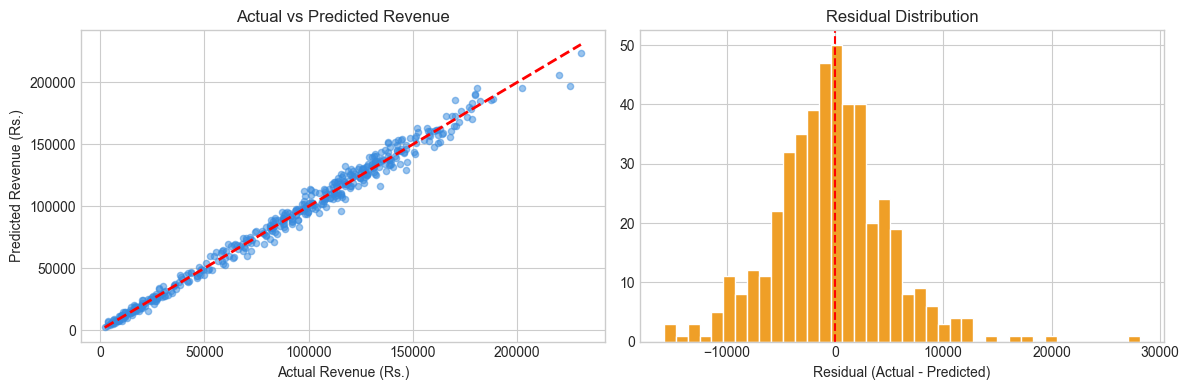


Final Results:
R²   : 0.9891
MAE  : Rs. 3,952
RMSE : Rs. 5,318


In [ ]:
# Evaluation plots
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='#378ADD', s=20)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Revenue (Rs.)')
axes[0].set_ylabel('Predicted Revenue (Rs.)')
axes[0].set_title('Actual vs Predicted Revenue')

residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=40, color='#EF9F27', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('../visuals/ml_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Results:")
print(f"R²   : {r2_score(y_test, y_pred_best):.4f}")
print(f"MAE  : Rs. {mean_absolute_error(y_test, y_pred_best):,.0f}")
print(f"RMSE : Rs. {np.sqrt(mean_squared_error(y_test, y_pred_best)):,.0f}")

In [ ]:
# ===== POWER BI KE LIYE DATA EXPORT =====

# 1. Master data
master.to_csv('powerbi_master.csv', index=False)

# 2. Weekly revenue with predictions
weekly_revenue['predicted_revenue'] = best_model.predict(
    weekly_revenue[features_clean])
weekly_revenue['prediction_error'] = (
    weekly_revenue['total_revenue'] - weekly_revenue['predicted_revenue'])
weekly_revenue.to_csv('../data/powerbi_weekly.csv', index=False)

# 3. Branch summary
branch_summary = master.groupby(['branch_id','city','area']).agg(
    total_revenue  = ('actual_price', 'sum'),
    total_profit   = ('profit', 'sum'),
    total_orders   = ('order_id', 'nunique'),
    avg_feedback   = ('feedback_score', 'mean'),
    avg_order_val  = ('order_total', 'mean')
).reset_index()
branch_summary['profit_margin_pct'] = (
    branch_summary['total_profit'] / 
    branch_summary['total_revenue'] * 100).round(2)
branch_summary.to_csv('../data/powerbi_branch_summary.csv', index=False)

# 4. Category summary  
category_summary = master.groupby('category').agg(
    total_revenue = ('actual_price', 'sum'),
    total_profit  = ('profit', 'sum'),
    total_items   = ('quantity', 'sum')
).reset_index()
category_summary.to_csv('../data/powerbi_category_summary.csv', index=False)

# 5. Monthly trend
monthly_trend = master.groupby(
    ['order_year','order_month','city']).agg(
    total_revenue = ('actual_price', 'sum'),
    total_orders  = ('order_id', 'nunique')
).reset_index()
monthly_trend.to_csv('../data/powerbi_monthly_trend.csv', index=False)

print("="*45)
print("POWER BI FILES EXPORTED!")
print("="*45)
print("powerbi_master.csv")
print("powerbi_weekly.csv")
print("powerbi_branch_summary.csv")
print("powerbi_category_summary.csv")
print("powerbi_monthly_trend.csv")

POWER BI FILES EXPORTED!
powerbi_master.csv
powerbi_weekly.csv
powerbi_branch_summary.csv
powerbi_category_summary.csv
powerbi_monthly_trend.csv
